## 야후 파이넨스(yfinance)
- yfinance는 전 세계 주식, ETF, 암호화폐의 실시간 및 과거 데이터를 코드 한 줄로 내 파이썬 노트북에 가져와주는 "무료 금융 데이터 치트키"라이브러리이다.
- 기존에 사이트에서 CSV파일을 다운로드 할 수 있지만, 종목이 많아지면 관리하기 어렵기 때문에 라이브러리 사용을 권장한다.  
[야후 파이넨스 공식 문서](https://finance.yahoo.com/)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

warnings.filterwarnings('ignore')

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


In [2]:
session = cffi_requests.Session(impersonate="chrome")
session

In [5]:
tickers = ["JEPQ","JEPI","NVDA","MSFT"]
all_data = {}

for t in tickers:
    df = yf.download(t, start="2024-01-01", end="2026-09-01", session=session, threads=False)
    all_data[t] = df
    time.sleep(5)

all_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


{'JEPQ': Price           Close       High        Low       Open   Volume
 Ticker           JEPQ       JEPQ       JEPQ       JEPQ     JEPQ
 Date                                                           
 2024-01-02  37.038410  37.195320  36.920353  37.195320  3137400
 2024-01-03  36.776901  36.920361  36.732069  36.881508  2316600
 2024-01-04  36.627453  36.874025  36.612509  36.664812  2790100
 2024-01-05  36.724594  36.896448  36.612514  36.642402  2798000
 2024-01-08  37.285004  37.292474  36.806797  36.814270  2124500
 ...               ...        ...        ...        ...      ...
 2026-08-25  59.072330  59.220631  58.849884  59.092104  4602500
 2026-08-26  59.111877  59.210742  58.924030  58.943804  4441800
 2026-08-27  59.625980  59.643774  59.279948  59.448022  4667600
 2026-08-28  59.467796  59.823710  59.388702  59.586434  6185300
 2026-08-31  59.537003  59.566661  59.319497  59.467797  8095700
 
 [668 rows x 5 columns],
 'JEPI': Price           Close       High        Low   

In [7]:
all_data["NVDA"].head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.028793,49.152535,47.457451,49.101684,411254000
2024-01-03,47.431530,48.044751,47.183249,47.347773,320896000
2024-01-04,47.859283,48.359832,47.370698,47.628948,306535000
2024-01-05,48.955109,49.403809,48.166394,48.321945,415039000
2024-01-08,52.101986,52.123926,49.336005,49.368910,642510000


In [9]:
all_data["NVDA"].columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

## 데이터 준비

In [10]:
close_df = pd.DataFrame()

for t in tickers:
    close_df[t]= all_data[t]["Close"]

print(close_df)

                 JEPQ       JEPI        NVDA        MSFT
Date                                                    
2024-01-02  37.038410  44.692699   48.028793  363.117920
2024-01-03  36.776901  44.441341   47.431530  362.853607
2024-01-04  36.627453  44.425133   47.859283  360.249176
2024-01-05  36.724594  44.392696   48.955109  360.063141
2024-01-08  37.285004  44.692699   52.101986  366.858093
...               ...        ...         ...         ...
2026-08-25  59.072330  57.764870  212.811874  491.709991
2026-08-26  59.111877  57.784740  209.425659  496.369995
2026-08-27  59.625980  57.476738  227.725174  505.059998
2026-08-28  59.467796  57.417130  217.306839  513.530029
2026-08-31  59.537003  57.128998  220.533234  507.290009

[668 rows x 4 columns]


## 데이터 전처리

In [12]:
# 결측치 없음
close_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 668 entries, 2024-01-02 to 2026-08-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JEPQ    668 non-null    float64
 1   JEPI    668 non-null    float64
 2   NVDA    668 non-null    float64
 3   MSFT    668 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [13]:
close_df.describe()

,JEPQ,JEPI,NVDA,MSFT
count,668.000000,668.000000,668.000000,668.000000
mean,47.879984,51.286075,147.299539,431.921963
std,6.121774,3.362889,43.831636,44.189094
min,36.627453,44.392696,47.431530,350.446075
25%,42.768608,48.528728,115.916492,400.007050
50%,47.085598,51.441778,141.016617,417.746323
75%,53.268999,54.248922,183.702614,470.046593
max,59.873146,57.784740,235.202393,537.646423


## 초기 가설
- NVDA, MSFT 개별 성장주이기에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다.
- JEPQ, JEPI 배당형 성장형 ETF이기에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다.
- 2024년도 조정기에 ETF 중 표준편차가 낮은 JEPI의 방어력이 가장 좋았을 것이다.

In [18]:
# .pct_change(): 변화율을 구해주는 함수
# ex) (오늘 종가 - 어제 종가) / 어제 종가
returns_df = close_df.pct_change().dropna()
returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.004064,-0.000365,0.009018,-0.007178
2024-01-05,0.002652,-0.000730,0.022897,-0.000516
2024-01-08,0.015260,0.006758,0.064281,0.018872
2024-01-09,0.002204,-0.000726,0.016975,0.002936
...,...,...,...,...
2026-08-25,0.005554,0.000861,0.021921,0.009029
2026-08-26,0.000669,0.000344,-0.015912,0.009477
2026-08-27,0.008697,-0.005330,0.087380,0.017507


In [20]:
# .cumprod()
cum_returns_df = (1 + returns_df).cumprod() - 1 
cum_returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.019287,-0.008413
2024-01-08,0.006658,0.000000,0.084807,0.010300
2024-01-09,0.008877,-0.000726,0.103222,0.013266
...,...,...,...,...
2026-08-25,0.594894,0.292490,3.430923,0.354133
2026-08-26,0.595962,0.292935,3.360419,0.366966
2026-08-27,0.609842,0.286043,3.741430,0.390898


In [22]:
# .cummax() : 이전 값과 비교하여 큰 값으로 대체
peak_df = close_df.cummax()
peak_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,37.038410,44.692699,48.028793,363.117920
2024-01-03,37.038410,44.692699,48.028793,363.117920
2024-01-04,37.038410,44.692699,48.028793,363.117920
2024-01-05,37.038410,44.692699,48.955109,363.117920
2024-01-08,37.285004,44.692699,52.101986,366.858093
...,...,...,...,...
2026-08-25,59.873146,57.764870,235.202393,537.646423
2026-08-26,59.873146,57.784740,235.202393,537.646423
2026-08-27,59.873146,57.784740,235.202393,537.646423


In [23]:
# 고점 대비 낙폭
drawdown_df = (close_df - peak_df) / peak_df
drawdown_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,0.000000,0.000000,0.000000,0.000000
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.000000,-0.008413
2024-01-08,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2026-08-25,-0.013375,0.000000,-0.095197,-0.085440
2026-08-26,-0.012715,0.000000,-0.109594,-0.076772
2026-08-27,-0.004128,-0.005330,-0.031791,-0.060609


In [33]:
# 수익의 변동성(표준편차) * 미주(휴장일을 제외하고 미국에서 장이 열리는 일수 = 252)
# = 연율화(미국 주식의 년단위 변동성)
annual_vol = returns_df.std() * np.sqrt(252)
annual_vol

mdd = drawdown_df.min()
mdd

v1_proof = pd.DataFrame({
    "최종 누적 수익률(%)": cum_returns_df.iloc[-1] * 100,
    "연율화 변동성(%)": annual_vol * 100,
    "최대 낙폭 MDD(%)": mdd * 100
})
v1_proof

,최종 누적 수익률(%),연율화 변동성(%),최대 낙폭 MDD(%)
JEPQ,60.743947,16.137045,-20.069929
JEPI,27.826241,10.279527,-13.257854
NVDA,359.168799,48.437012,-36.881027
MSFT,39.703931,26.850657,-34.498398


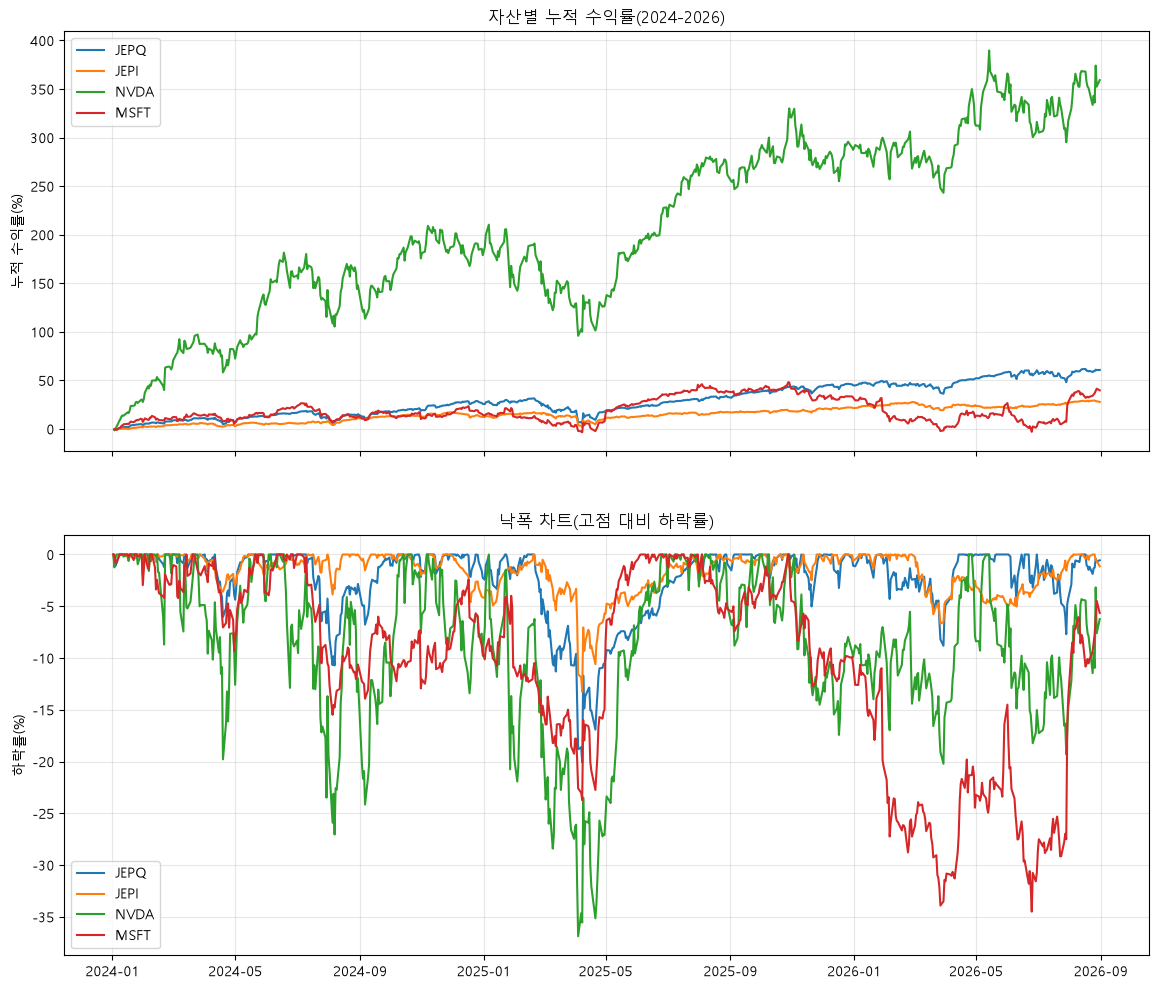

In [40]:
fig, axes = plt.subplots(2,1, figsize=(14,12), sharex=True)

for t in tickers:
    # x축 : cum_returns_df(일자), y축 : cum_returns_df[t] * 100(일자별 누적 수익률)
    axes[0].plot(cum_returns_df.index, cum_returns_df[t] * 100, label=t)
    axes[0].set_title("자산별 누적 수익률(2024-2026)")
    axes[0].set_ylabel("누적 수익률(%)")
    axes[0].legend()
    # alpha=0.3: 투명도 30%
    axes[0].grid(True, alpha=0.3)

for t in tickers:
    axes[1].plot(drawdown_df.index, drawdown_df[t] * 100, label=t)
    axes[1].set_title("낙폭 차트(고점 대비 하락률)")
    axes[1].set_ylabel("하락률(%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.show()

## 검증
- NVDA, MSFT 개별 성장주이기에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다. -> 참(NVDA우상향)
- JEPQ, JEPI 배당형 성장형 ETF이기에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다. -> 참(-36%,-34% 깎이는 와중에 13%만 하락)
- 2024년도 조정기에 ETF 중 표준편차가 낮은 JEPI의 방어력이 가장 좋았을 것이다. -> 참(13% 하락한 게 JEPI)

## 가설2
- JPEQ,JEPI 배당형 ETF
- JEPQ: 나스닥 100 기반으로 상장된 ETF -> NVDA, MSFT와 높은 상관관계를 가질 것이다.
- JEPI: S&P 500 기반으로 상장된 ETF -> NVDA, MSFT와 낮은 상관관계를 가질 것이다.

In [45]:
# .rolling(): 20일 설정
# .corr(): 최근 20일간의 상관관계를 매일 계산해서 반환
rolling_jpei = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPI"])
rolling_jpeq = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPQ"])

rolling_jpei

Date
2024-01-03         NaN
2024-01-04         NaN
2024-01-05         NaN
2024-01-08         NaN
2024-01-09         NaN
                ...   
2026-08-25    0.424743
2026-08-26    0.215704
2026-08-27   -0.286667
2026-08-28   -0.247929
2026-08-31   -0.362132
Length: 667, dtype: float64

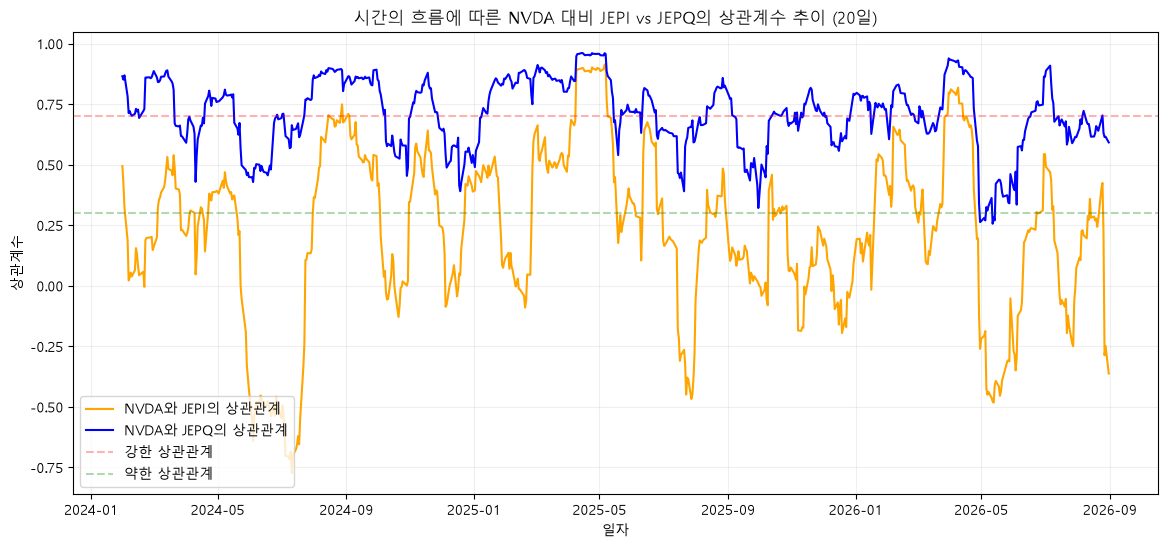

In [53]:
plt.figure(figsize=(14,6))
plt.plot(rolling_jpei.index, rolling_jpei, label="NVDA와 JEPI의 상관관계",color="orange")
plt.plot(rolling_jpeq.index, rolling_jpeq, label="NVDA와 JEPQ의 상관관계",color="blue")

plt.axhline(0.7, color="red",linestyle="--", alpha=0.3, label= "강한 상관관계")
plt.axhline(0.3, color="green",linestyle="--", alpha=0.3, label= "약한 상관관계")

plt.title("시간의 흐름에 따른 NVDA 대비 JEPI vs JEPQ의 상관계수 추이 (20일)")
plt.ylabel("상관계수")
plt.xlabel("일자")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)
plt.show()

## 가설 검증 결과
- JEPQ와 NVDA는 0.7이상의 높은 지속적 상관관계를 유지하며 동조화가 잘 되고 있다.
- 반대로 JEPI는 NVDA와의 상관관계가 0.4 이상의 낮은 상관관계를 유지하며 동조화가 되고 있다.
- 성장주(NVDA) 리스크 분산을 하고 싶을 때에는 JEPI를 추천해서 자산을 배분해야한다.
- 가설은 참(채택)

## EDA 시각화
역사적 고점 대비 대략 20% 떨어졌을 때 산 이후 한달 뒤에 수익을 볼 확률, 평균 수익률

In [67]:
forward_days = 20
results = []
for t in tickers:
    # 20일 뒤 주가 / 현재 주가 - 1 = 20일동안의 수익률
    fwd_return_df = (close_df[t].shift(-forward_days) / close_df[t])-1

    drawdown = drawdown_df[t]
    df_temp = pd.DataFrame({"Drawdown": drawdown, "FwdReturn":fwd_return_df}).dropna()
    

    # 구간
    bins = [-1.0, -0.2, -0.1, -0.05, 0.001]
    labels = ["-20% 이하(대폭락)", "-10% ~ -20%", "-5%, -10%", "-0% ~ -5%"]

    df_temp["구간"] = pd.cut(df_temp["Drawdown"], bins=bins, labels=labels)

# 구간별 통계 집계
    for label in labels:
        sub_df = df_temp[df_temp["구간"]==label]

        if len(sub_df) > 0:
            win_rate = (sub_df["FwdReturn"] > 0).mean() * 100 # 수익을 볼 확률
            avg_rate = sub_df["FwdReturn"].mean() * 100 # 평균 수익률
            
            results.append({
                "종목": t,
                "낙폭 구간": label,
                "진입 횟수(일)": len(sub_df),
                "1개월 뒤 승률(%)": win_rate,
                "1개월 뒤 평균 수익률(%)": avg_rate
            })

prob_df = pd.DataFrame(results)
prob_df

,종목,낙폭 구간,진입 횟수(일),1개월 뒤 승률(%),1개월 뒤 평균 수익률(%)
0,JEPQ,-20% 이하(대폭락),1,100.000000,13.484022
1,JEPQ,-10% ~ -20%,27,77.777778,3.940399
2,JEPQ,"-5%, -10%",80,78.750000,2.140770
3,JEPQ,-0% ~ -5%,540,73.518519,1.201905
4,JEPI,-10% ~ -20%,4,100.000000,8.186309
5,JEPI,"-5%, -10%",23,95.652174,2.954741
6,JEPI,-0% ~ -5%,621,70.531401,0.660211
7,NVDA,-20% 이하(대폭락),63,66.666667,9.943815
8,NVDA,-10% ~ -20%,176,73.863636,4.830248
9,NVDA,"-5%, -10%",169,45.562130,0.567434


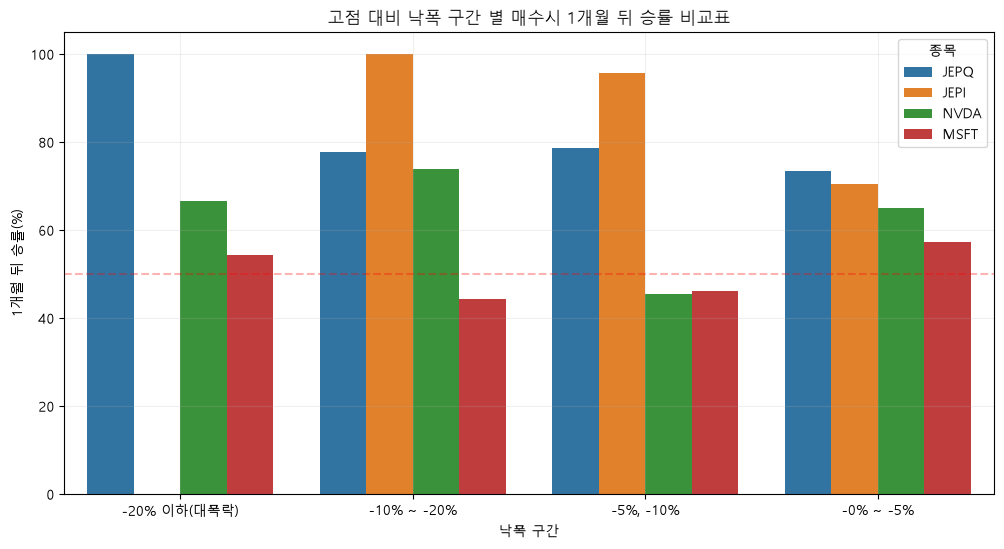

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(data=prob_df, x="낙폭 구간", y="1개월 뒤 승률(%)", hue="종목")

plt.axhline(50, color="red", linestyle="--", alpha=0.3)

plt.title("고점 대비 낙폭 구간 별 매수시 1개월 뒤 승률 비교표")
plt.grid(True, alpha = 0.2)
plt.show()

## 결론
- 조정기(-10% ~ -20%)에는 개별 성장주의 승률보다 ETF 주식의 승률이 극대화되었다(JEPQ 약 13.4%).
- (-5% ~ -10%) 구간에서 개별 성장주의 승률은 오히려 50%보다 낮게 기록되었다.
- 지수형 커버드콜(JEPQ) ETF는 -20%이하 대폭락이 왔을 때 개별 성장주를 압도하는 리턴과 승률을 안겨주는 인사이트를 제공하고 있다.